# Análisis descriptivo — Matrículas de Educación Superior 2021
## Región de Arica y Parinacota

**Fuente de datos**: Registro de Matrícula de Educación Superior año 2021 (SIES), archivo
`01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx`.

Las 28 variables del archivo están descritas en el *diccionario de variables* (`docs/diccionario_variables.pdf`).
Cada fila representa una **matrícula** (no un estudiante): un estudiante matriculado en dos carreras aparece dos veces.

El análisis se desarrolla con las funciones del **Formulario Python MAT4141** (tablas de frecuencia con
`groupby` y `pd.cut`, gráficos circular/de barras/histograma con `matplotlib`, medidas de tendencia central,
percentiles y dispersión), complementado únicamente con `pd.crosstab` para las tablas de dos variables.

## Carga de la base de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../raw/01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx")

In [2]:
#Número de filas y columnas
filas = df.shape[0]
columnas = df.shape[1]
print(f"El conjunto tiene {filas} matrículas y {columnas} variables.")
df.head(5)

El conjunto tiene 14116 matrículas y 28 variables.


,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,1,Femenino,22,20 a 24,2019,Primer semestre,Centros de Formacion Tecnica,CFT DE TARAPACA,NO ACREDITADA,NaN,...,Carreras Tecnicas,Salud,5,1,5,120000,1823000,Arica y Parinacota,Arica,Arica
1,27,Femenino,26,25 a 29,2020,Primer semestre,Institutos Profesionales,IP SANTO TOMAS,ACREDITADA,20/01/2021 AL 20/01/2026,...,Carreras Profesionales,Administracion y Comercio,4,0,4,89000,1855000,Arica y Parinacota,Arica,Arica
2,38,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE TARAPACA,ACREDITADA,22/11/2017 AL 22/11/2022,...,Carreras Profesionales,Salud,10,1,10,155000,3533000,Arica y Parinacota,Arica,Arica
3,193,Femenino,23,20 a 24,2016,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE TARAPACA,ACREDITADA,22/11/2017 AL 22/11/2022,...,Carreras Profesionales,Salud,10,1,10,155000,3533000,Arica y Parinacota,Arica,Arica
4,472,Femenino,20,20 a 24,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE TARAPACA,ACREDITADA,22/11/2017 AL 22/11/2022,...,Carreras Profesionales,Educacion,10,1,10,155000,2857000,Arica y Parinacota,Arica,Arica


---
# **Ítem 1** — Análisis descriptivo del conjunto de datos

Se seleccionaron las variables más relevantes para describir el conjunto en tres dimensiones:

1. **Quién se matricula**: `GENERO`, `EDAD`, `RANGO EDAD`.
2. **Dónde se matricula**: `TIPO DE INSTITUCION`, `ACREDITACION INSTITUCIONAL`, `JORNADA`.
3. **Qué estudia y cuánto paga**: `NIVEL CARRERA`, `AREA CONOCIMIENTO`, `AÑO INGRESO`,
   `DURACION TOTAL CARRERA (SEMESTRES)`, `VALOR ARANCEL (PESOS)`.

Comienza con las **variables cualitativas** (tabla de frecuencia absoluta `fi` y relativa porcentual `hi`,
más su gráfico), sigue con las **cuantitativas** (tabla con intervalos, histograma, medidas de tendencia
central, percentiles y dispersión) y cierra con tablas de **dos variables** y otros resúmenes.

### 1.1 Variable cualitativa: `GENERO`

El 56,6 % de las matrículas corresponde a mujeres y el 43,4 % a hombres: la matrícula femenina es
mayoría en la región, superando en más de 13 puntos porcentuales a la masculina.

In [3]:
#Tabla de frecuencia: GENERO
frecuencia = df.groupby('GENERO').size()
n = df.shape[0]

tabla_genero = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_genero

,fi,hi
GENERO,,
Femenino,7993,56.6
Masculino,6123,43.4


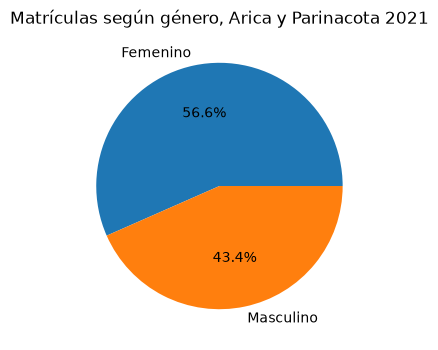

In [4]:
#Gráfico circular: GENERO
categorias = tabla_genero.index
h = tabla_genero['hi']

fig, ax = plt.subplots(figsize=(6,4))
circular = ax.pie(h, labels=categorias, autopct='%.1f%%')
ax.set_title('Matrículas según género, Arica y Parinacota 2021')
plt.show()

### 1.2 Variable cualitativa: `TIPO DE INSTITUCION`

Las **Universidades CRUCH** concentran el 55,6 % de las matrículas (7.849), seguidas por los
**Centros de Formación Técnica** con 25,5 %. Los Institutos Profesionales (10,1 %) y las
Universidades Privadas no CRUCH (8,8 %) tienen participaciones menores. En la región la oferta está
fuertemente dominada por la Universidad de Tarapacá (estatal, CRUCH), lo que explica esta concentración.

In [5]:
#Tabla de frecuencia: TIPO DE INSTITUCION
frecuencia = df.groupby('TIPO DE INSTITUCION').size()
n = df.shape[0]

tabla_tipo_inst = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_tipo_inst

,fi,hi
TIPO DE INSTITUCION,,
Centros de Formacion Tecnica,3594,25.5
Institutos Profesionales,1430,10.1
Universidades CRUCH,7849,55.6
Universidades Privadas,1243,8.8


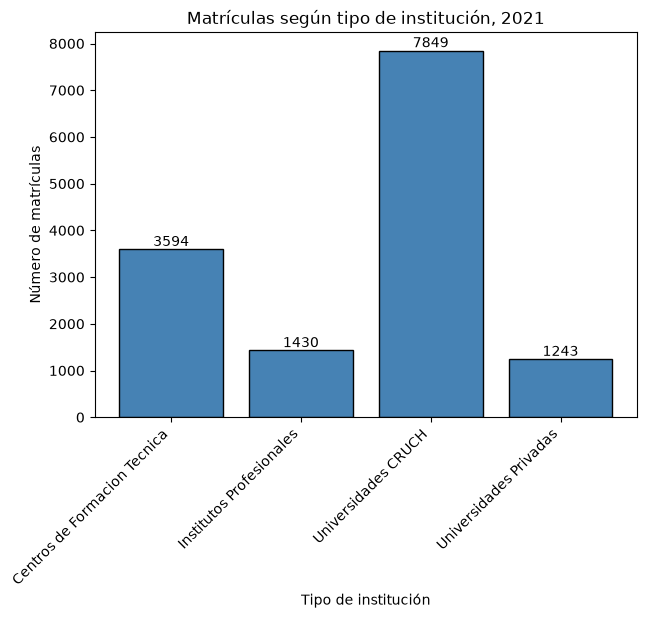

In [6]:
#Gráfico de barras: TIPO DE INSTITUCION
categorias = tabla_tipo_inst.index
f = tabla_tipo_inst['fi']

fig, ax = plt.subplots(figsize=(7,5))
barras = ax.bar(categorias, f, color='steelblue', edgecolor='black')
ax.set_title('Matrículas según tipo de institución, 2021')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.show()

### 1.3 Variable cualitativa: `ACREDITACION INSTITUCIONAL`

El 83,4 % de las matrículas se realizó en instituciones **acreditadas** y solo 16,6 % en instituciones
**no acreditadas**. Es un aspecto positivo para la región: la gran mayoría de los estudiantes estudia
en instituciones con acreditación vigente al 30 de abril de 2021 (lo que además habilita el acceso a
gratuidad y beneficios estatales).

In [7]:
#Tabla de frecuencia: ACREDITACION INSTITUCIONAL
frecuencia = df.groupby('ACREDITACION INSTITUCIONAL').size()
n = df.shape[0]

tabla_acred = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_acred

,fi,hi
ACREDITACION INSTITUCIONAL,,
ACREDITADA,11773,83.4
NO ACREDITADA,2343,16.6


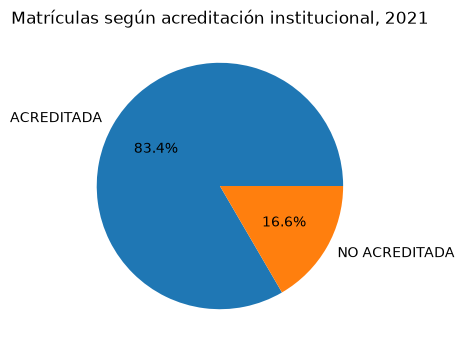

In [8]:
#Gráfico circular: ACREDITACION INSTITUCIONAL
categorias = tabla_acred.index
h = tabla_acred['hi']

fig, ax = plt.subplots(figsize=(6,4))
circular = ax.pie(h, labels=categorias, autopct='%.1f%%')
ax.set_title('Matrículas según acreditación institucional, 2021')
plt.show()

### 1.4 Variable cualitativa: `NIVEL CARRERA`

Predominan las **Carreras Profesionales** con 70,8 % de las matrículas, seguidas de las
**Carreras Técnicas** con 28,2 %. Los programas de postgrado son marginales en la región:
111 matrículas de Magíster (0,8 %), 16 de Doctorado y 1 de Postítulo. Esto refleja que la oferta
local de postgrado es todavía incipiente, concentrada en la Universidad de Tarapacá.

In [9]:
#Tabla de frecuencia: NIVEL CARRERA
frecuencia = df.groupby('NIVEL CARRERA').size()
n = df.shape[0]

tabla_nivel = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_nivel

,fi,hi
NIVEL CARRERA,,
Carreras Profesionales,10001,70.8
Carreras Tecnicas,3987,28.2
Doctorado,16,0.1
Magister,111,0.8
Postitulo,1,0.0


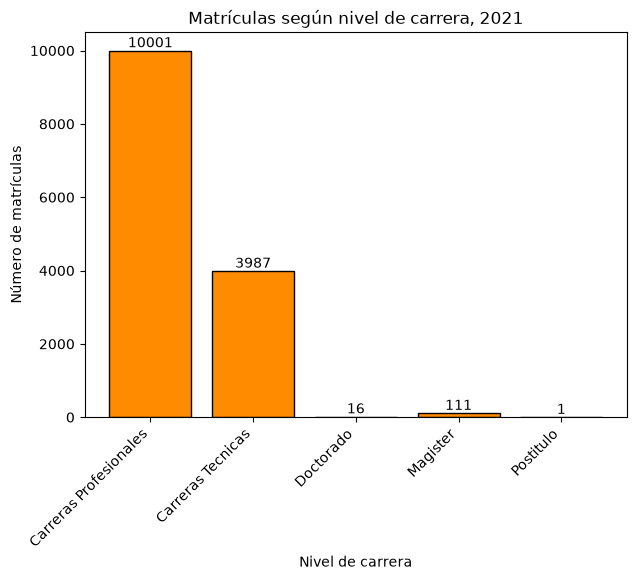

In [10]:
#Gráfico de barras: NIVEL CARRERA
categorias = tabla_nivel.index
f = tabla_nivel['fi']

fig, ax = plt.subplots(figsize=(7,5))
barras = ax.bar(categorias, f, color='darkorange', edgecolor='black')
ax.set_title('Matrículas según nivel de carrera, 2021')
ax.set_xlabel('Nivel de carrera')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.show()

### 1.5 Variable cualitativa: `JORNADA`

El 70,6 % de las matrículas es en jornada **diurna** y el 29,1 % **vespertina**. La jornada vespertina
es relevante en la región: está asociada a estudiantes que trabajan o a población de mayor edad,
como se confirmará al cruzar edad con tipo de institución en el Ítem 2.

In [11]:
#Tabla de frecuencia: JORNADA
frecuencia = df.groupby('JORNADA').size()
n = df.shape[0]

tabla_jornada = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_jornada

,fi,hi
JORNADA,,
Diurno,9961,70.6
Otro,47,0.3
Semipresencial,4,0.0
Vespertino,4104,29.1


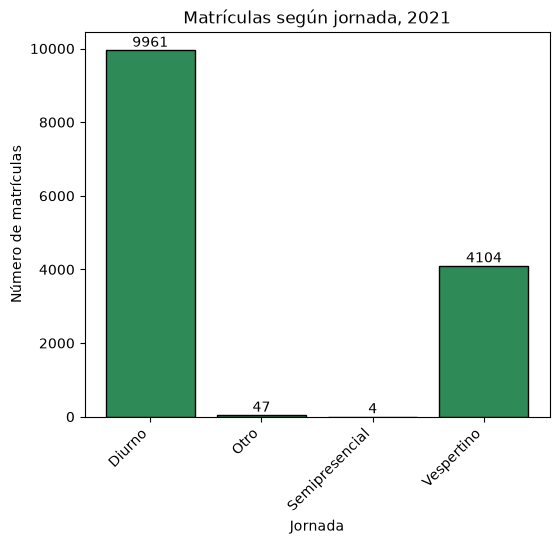

In [12]:
#Gráfico de barras: JORNADA
categorias = tabla_jornada.index
f = tabla_jornada['fi']

fig, ax = plt.subplots(figsize=(6,5))
barras = ax.bar(categorias, f, color='seagreen', edgecolor='black')
ax.set_title('Matrículas según jornada, 2021')
ax.set_xlabel('Jornada')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.show()

### 1.6 Variable cualitativa: `RANGO EDAD`

El tramo **20 a 24 años** concentra el 46,5 % de las matrículas; sumado al tramo 15 a 19 (17,2 %),
casi dos de cada tres matrículas son de menores de 25 años. Aun así, un 19,4 % tiene 30 años o más,
lo que da cuenta de una matrícula con presencia importante de adultos que se (re)incorporan a la
educación superior.

In [13]:
#Tabla de frecuencia: RANGO EDAD
frecuencia = df.groupby('RANGO EDAD').size()
n = df.shape[0]

tabla_rango_edad = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_rango_edad

,fi,hi
RANGO EDAD,,
15 a 19,2429,17.2
20 a 24,6558,46.5
25 a 29,2387,16.9
30 a 34,1130,8.0
35 a 39,720,5.1
40 y mas,892,6.3


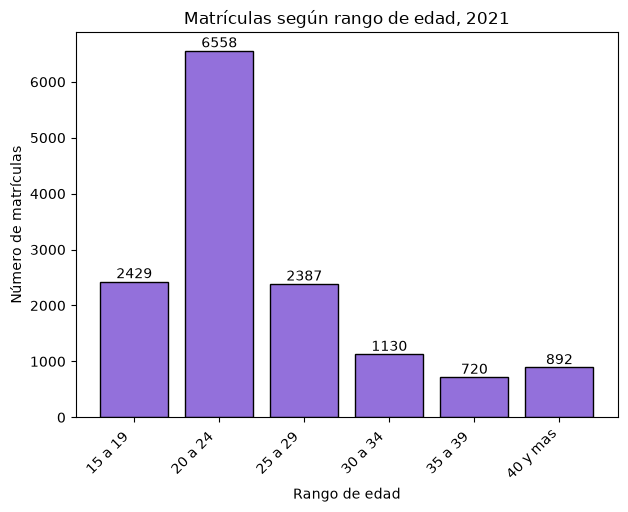

In [14]:
#Gráfico de barras: RANGO EDAD
categorias = tabla_rango_edad.index
f = tabla_rango_edad['fi']

fig, ax = plt.subplots(figsize=(7,5))
barras = ax.bar(categorias, f, color='mediumpurple', edgecolor='black')
ax.set_title('Matrículas según rango de edad, 2021')
ax.set_xlabel('Rango de edad')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.show()

### 1.7 Variable cualitativa: `AREA CONOCIMIENTO`

Las tres áreas con más matrículas son **Tecnología** (2.979 mat., 21,1 %), **Salud** (2.899 mat.,
20,5 %) y **Administración y Comercio** (2.254 mat., 16,0 %); les siguen Educación (14,6 %) y
Ciencias Sociales (14,0 %). Las áreas con menor matrícula son Ciencias Básicas (1,3 %) y Humanidades
(1,6 %), típicas de una región donde la oferta está orientada a demandas laborales locales (salud,
administración, tecnología).

In [15]:
#Tabla de frecuencia: AREA CONOCIMIENTO (ordenada de mayor a menor fi)
frecuencia = df.groupby('AREA CONOCIMIENTO').size().sort_values(ascending=False)
n = df.shape[0]

tabla_area = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_area

,fi,hi
AREA CONOCIMIENTO,,
Tecnologia,2979,21.1
Salud,2899,20.5
Administracion y Comercio,2254,16.0
Educacion,2060,14.6
Ciencias Sociales,1972,14.0
Derecho,751,5.3
Agropecuaria,534,3.8
Arte y Arquitectura,249,1.8
Humanidades,231,1.6


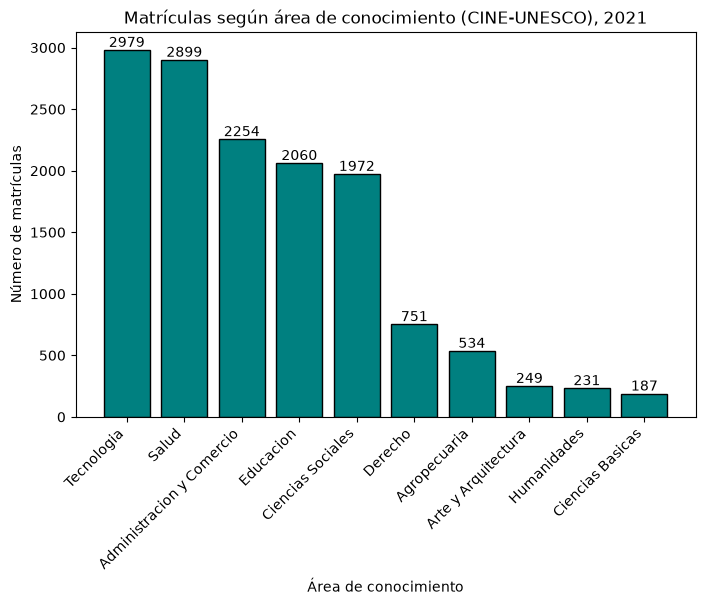

In [16]:
#Gráfico de barras: AREA CONOCIMIENTO
categorias = tabla_area.index
f = tabla_area['fi']

fig, ax = plt.subplots(figsize=(8,5))
barras = ax.bar(categorias, f, color='teal', edgecolor='black')
ax.set_title('Matrículas según área de conocimiento (CINE-UNESCO), 2021')
ax.set_xlabel('Área de conocimiento')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.show()

### 1.8 Variable cualitativa: `AÑO INGRESO`

El 37,1 % de las matrículas vigentes en 2021 corresponde a estudiantes que ingresaron ese mismo año;
el resto son cohortes anteriores que continúan activas (2020: 18,8 %, 2019: 15,4 %, etc.). Hay incluso
matrículas con año de ingreso tan antiguo como 2007, lo que sugiere trayectorias académicas muy
alargadas en algunas carreras.

In [17]:
#Tabla de frecuencia: AÑO INGRESO
frecuencia = df.groupby('AÑO INGRESO').size().sort_index(ascending=False)
n = df.shape[0]

tabla_anio = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1)
})
tabla_anio

,fi,hi
AÑO INGRESO,,
2021,5233,37.1
2020,2656,18.8
2019,2180,15.4
2018,1493,10.6
2017,1049,7.4
2016,754,5.3
2015,368,2.6
2014,157,1.1
2013,97,0.7


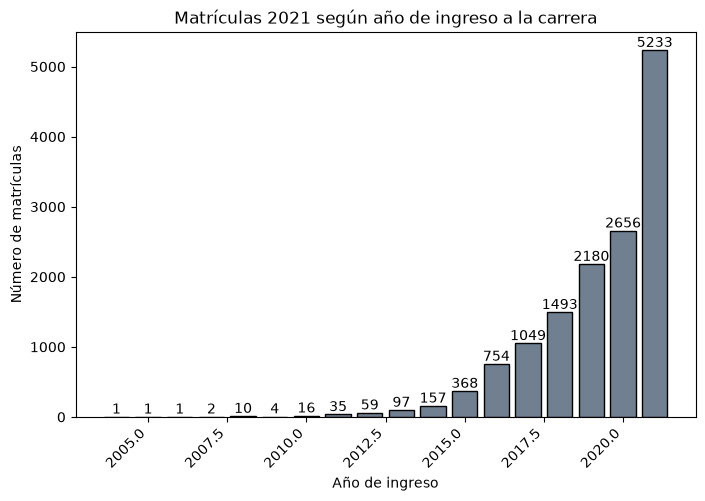

In [18]:
#Gráfico de barras: AÑO INGRESO
categorias = tabla_anio.index
f = tabla_anio['fi']

fig, ax = plt.subplots(figsize=(8,5))
barras = ax.bar(categorias, f, color='slategray', edgecolor='black')
ax.set_title('Matrículas 2021 según año de ingreso a la carrera')
ax.set_xlabel('Año de ingreso')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.show()

### 1.9 Variable cuantitativa continua: `EDAD`

**Criterio de intervalos**: regla de Sturges, $k = 1 + \log_2 n = 1 + \log_2 14116 \approx 15$ intervalos,
ajustados a bordes redondos de ancho 4 años entre 16 y 76.

La distribución es **asimétrica a la derecha**: la media (25,5 años) supera a la mediana (23 años) y la
moda es 19 años. El 50 % central tiene entre 21 y 28 años (RIC = 7 años) y la desviación estándar es
7,4 años (CV ≈ 29,1 %). El percentil 90 es 36 años: solo el 10 % de las matrículas tiene 36 años o más,
con casos extremos hasta los 75 años.

In [19]:
#Cantidad de intervalos según Sturges, ajustado a bordes redondos
k = int(round(1 + np.log2(df.shape[0])))   # k = 15
intervalos_edad = np.arange(16, 77, 4)     # 15 intervalos de ancho 4: [16,20), ..., [72,76]

df['Intervalos EDAD'] = pd.cut(df['EDAD'], bins=intervalos_edad, include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos EDAD', observed=True).size()

n = df.shape[0]
tabla_edad = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
tabla_edad

,fi,hi,Fi,Hi
Intervalos EDAD,,,,
"(15, 20]",3209,22.7,3209,22.7
"(20, 24]",5778,40.9,8987,63.7
"(24, 28]",1857,13.2,10844,76.8
"(28, 32]",1152,8.2,11996,85.0
"(32, 36]",756,5.4,12752,90.3
"(36, 40]",510,3.6,13262,94.0
"(40, 44]",342,2.4,13604,96.4
"(44, 48]",243,1.7,13847,98.1
"(48, 52]",155,1.1,14002,99.2


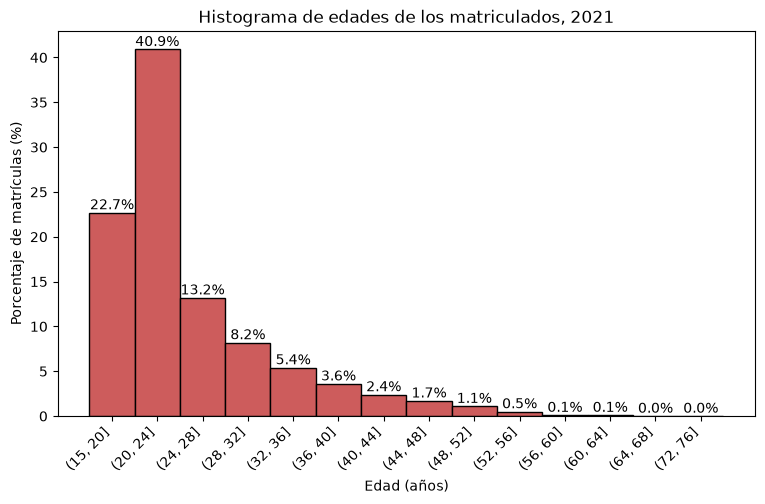

In [20]:
#Histograma: EDAD
categorias = tabla_edad.index
f = tabla_edad['hi']

fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(categorias.astype(str), f, color='indianred', edgecolor='black', width=1)
ax.set_title('Histograma de edades de los matriculados, 2021')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.show()

In [21]:
#Medidas de tendencia central, percentiles y dispersión: EDAD
media_edad = df['EDAD'].mean()
mediana_edad = df['EDAD'].median()
moda_edad = df['EDAD'].mode()[0]
p25_edad = df['EDAD'].quantile(0.25)
p50_edad = df['EDAD'].quantile(0.50)
p75_edad = df['EDAD'].quantile(0.75)
p90_edad = df['EDAD'].quantile(0.90)
desviacion_edad = df['EDAD'].std()
cv_edad = round(desviacion_edad/media_edad*100, 1)
ric_edad = p75_edad - p25_edad

resumen_edad = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P50', 'P75', 'P90',
               'Desv. estándar', 'Coef. variación (%)', 'Rango intercuartílico', 'Mínimo', 'Máximo'],
    'Valor': [round(media_edad,1), mediana_edad, moda_edad, p25_edad, p50_edad, p75_edad, p90_edad,
              round(desviacion_edad,1), cv_edad, ric_edad, df['EDAD'].min(), df['EDAD'].max()]
})
resumen_edad

,Medida,Valor
0,Media,25.5
1,Mediana,23.0
2,Moda,19.0
3,P25,21.0
4,P50,23.0
5,P75,28.0
6,P90,36.0
7,Desv. estándar,7.4
8,Coef. variación (%),29.1
9,Rango intercuartílico,7.0


### 1.10 Variable cuantitativa continua: `VALOR ARANCEL (PESOS)`

**Criterio de intervalos**: Sturges da $k \approx 15$; se ajustan a intervalos de ancho
\$400.000 entre \$0 y \$6.000.000.

El arancel anual medio es **\$2.714.574** y el mediano **\$2.857.000**; como la media es menor que la
mediana, la distribución es **asimétrica a la izquierda**: hay muchas carreras con aranceles altos
(modales en \$3.533.000, el arancel de las carreras profesionales de la U. de Tarapacá) y pocas con
aranceles bajos. El 50 % central va de \$1.850.000 a \$3.533.000 (RIC = \$1.683.000) y la desviación
estándar es \$956.750 (CV ≈ 35,2 %).

**Dato llamativo**: existen 5 matrículas con arancel \$0, todas del Magíster en Acuicultura de la
Universidad de Tarapacá (programa de postgrado, posiblemente becado o sin arancel informado).

In [22]:
#Intervalos de ancho $400.000 según Sturges (k = 15)
intervalos_arancel = np.arange(0, 6000001, 400000)

df['Intervalos ARANCEL'] = pd.cut(df['VALOR ARANCEL (PESOS)'], bins=intervalos_arancel,
                                  include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos ARANCEL', observed=True).size()

n = df.shape[0]
tabla_arancel = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
tabla_arancel

,fi,hi,Fi,Hi
Intervalos ARANCEL,,,,
"(-1, 400000]",6,0.0,6,0.0
"(400000, 800000]",44,0.3,50,0.4
"(800000, 1200000]",4,0.0,54,0.4
"(1200000, 1600000]",2507,17.8,2561,18.1
"(1600000, 2000000]",1708,12.1,4269,30.2
"(2000000, 2400000]",1604,11.4,5873,41.6
"(2400000, 2800000]",488,3.5,6361,45.1
"(2800000, 3200000]",1857,13.2,8218,58.2
"(3200000, 3600000]",3667,26.0,11885,84.2


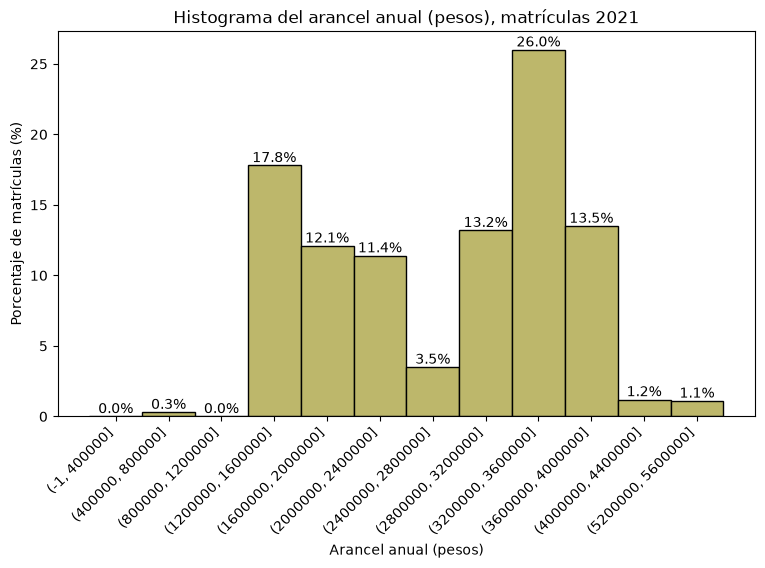

In [23]:
#Histograma: VALOR ARANCEL (PESOS)
categorias = tabla_arancel.index
f = tabla_arancel['hi']

fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(categorias.astype(str), f, color='darkkhaki', edgecolor='black', width=1)
ax.set_title('Histograma del arancel anual (pesos), matrículas 2021')
ax.set_xlabel('Arancel anual (pesos)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.show()

In [24]:
#Medidas de tendencia central, percentiles y dispersión: VALOR ARANCEL
arancel = df['VALOR ARANCEL (PESOS)']

media_arancel = arancel.mean()
mediana_arancel = arancel.median()
moda_arancel = arancel.mode()[0]
p25_arancel = arancel.quantile(0.25)
p75_arancel = arancel.quantile(0.75)
p90_arancel = arancel.quantile(0.90)
p95_arancel = arancel.quantile(0.95)
desviacion_arancel = arancel.std()
cv_arancel = round(desviacion_arancel/media_arancel*100, 1)
ric_arancel = p75_arancel - p25_arancel

resumen_arancel = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P75', 'P90', 'P95',
               'Desv. estándar', 'Coef. variación (%)', 'Rango intercuartílico', 'Mínimo', 'Máximo'],
    'Valor': [round(media_arancel), mediana_arancel, moda_arancel, p25_arancel, p75_arancel,
              p90_arancel, p95_arancel, round(desviacion_arancel), cv_arancel, ric_arancel,
              arancel.min(), arancel.max()]
})
resumen_arancel

,Medida,Valor
0,Media,2714574.0
1,Mediana,2857000.0
2,Moda,3533000.0
3,P25,1850000.0
4,P75,3533000.0
5,P90,3775000.0
6,P95,3995000.0
7,Desv. estándar,956750.0
8,Coef. variación (%),35.2
9,Rango intercuartílico,1683000.0


In [25]:
#Matrículas con arancel $0: ¿qué carreras son?
df.loc[df['VALOR ARANCEL (PESOS)'] == 0,
       ['NOMBRE CARRERA', 'NOMBRE DE INSTITUCION', 'NIVEL CARRERA']].drop_duplicates()

,NOMBRE CARRERA,NOMBRE DE INSTITUCION,NIVEL CARRERA
543,MAGISTER EN ACUICULTURA,UNIVERSIDAD ARTURO PRAT,Magister


### 1.11 Variable cuantitativa discreta: `DURACION TOTAL CARRERA (SEMESTRES)`

La duración modal es **10 semestres** (33,5 % de las matrículas, las carreras profesionales de la
Universidad de Tarapacá), seguida de 5 semestres (22,9 %, típico de carreras técnicas) y 8 semestres
(16,3 %). La duración media es ≈ 8,3 semestres y la mediana 9: la matrícula de la región se reparte
entre programas técnicos cortos y programas profesionales largos. Las 157 matrículas de 14 semestres
corresponden a Medicina.

In [26]:
#Tabla de frecuencia: DURACION TOTAL CARRERA (SEMESTRES) — variable discreta
frecuencia = df.groupby('DURACION TOTAL CARRERA (SEMESTRES)').size()
n = df.shape[0]

tabla_duracion = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
tabla_duracion

,fi,hi,Fi,Hi
DURACION TOTAL CARRERA (SEMESTRES),,,,
1,1,0.0,1,0.0
2,19,0.1,20,0.1
4,1037,7.3,1057,7.5
5,3239,22.9,4296,30.4
6,2,0.0,4298,30.4
8,2297,16.3,6595,46.7
9,690,4.9,7285,51.6
10,4732,33.5,12017,85.1
11,908,6.4,12925,91.6


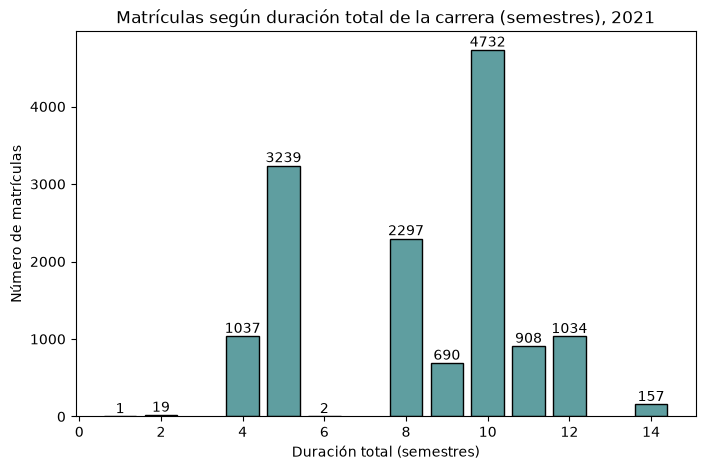

In [27]:
#Gráfico de barras: DURACION TOTAL CARRERA
categorias = tabla_duracion.index
f = tabla_duracion['fi']

fig, ax = plt.subplots(figsize=(8,5))
barras = ax.bar(categorias, f, color='cadetblue', edgecolor='black')
ax.set_title('Matrículas según duración total de la carrera (semestres), 2021')
ax.set_xlabel('Duración total (semestres)')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.show()

### 1.12 Tablas de frecuencia con dos variables (`pd.crosstab`)

**Tipo de institución × Nivel de carrera**: la estructura es completamente coherente con la normativa
chilena — los CFT solo imparten carreras técnicas (3.594 matrículas técnicas y 0 profesionales); los
IP imparten principalmente carreras profesionales (1.300) y algunas técnicas (130); las Universidades
CRUCH concentran las carreras profesionales (7.463), 263 técnicas y prácticamente todo el postgrado
(107 de los 111 magísteres y los 16 doctorados); las universidades privadas aportan 1.238
profesionales, 4 magísteres y 1 postítulo.

In [28]:
#Tabla de doble entrada: TIPO DE INSTITUCION x NIVEL CARRERA
pd.crosstab(df['TIPO DE INSTITUCION'], df['NIVEL CARRERA'])

NIVEL CARRERA,Carreras Profesionales,Carreras Tecnicas,Doctorado,Magister,Postitulo
TIPO DE INSTITUCION,,,,,
Centros de Formacion Tecnica,0,3594,0,0,0
Institutos Profesionales,1300,130,0,0,0
Universidades CRUCH,7463,263,16,107,0
Universidades Privadas,1238,0,0,4,1


**Género × Área de conocimiento** (porcentajes por fila, es decir, dentro de cada género):
se observa una fuerte **segregación por género**: entre las mujeres destacan Salud (25,8 %),
Educación (20,1 %) y Ciencias Sociales (18,1 %); entre los hombres, Tecnología concentra el 39,9 %
de sus matrículas. Administración y Comercio es el área más equilibrada (16,4 % mujeres vs 15,4 % hombres).

In [29]:
#Tabla de doble entrada con porcentajes por fila: GENERO x AREA CONOCIMIENTO
pd.crosstab(df['GENERO'], df['AREA CONOCIMIENTO'], normalize='index').round(3)*100

AREA CONOCIMIENTO,Administracion y Comercio,Agropecuaria,Arte y Arquitectura,Ciencias Basicas,Ciencias Sociales,Derecho,Educacion,Humanidades,Salud,Tecnologia
GENERO,,,,,,,,,,
Femenino,16.4,3.0,1.7,1.0,18.1,5.6,20.1,1.6,25.8,6.7
Masculino,15.4,4.9,1.9,1.7,8.6,5.0,7.3,1.7,13.7,39.9


### 1.13 Otros resúmenes

`describe()` entrega de una vez las principales medidas para todas las variables cuantitativas.
Se destaca: la matrícula 2021 involucra **11 instituciones** y **146 carreras** distintas; la
`VALOR MATRICULA` toma pocos valores (cada institución fija el suyo, entre \$0 y \$220.000).

In [30]:
#Resumen estadístico general de las variables cuantitativas
df[['EDAD', 'AÑO INGRESO', 'DURACION TOTAL CARRERA (SEMESTRES)',
    'VALOR MATRICULA (PESOS)', 'VALOR ARANCEL (PESOS)']].describe().round(1)

,EDAD,AÑO INGRESO,DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS)
count,14116.0,14116.0,14116.0,14116.0,14116.0
mean,25.5,2019.2,8.3,131952.4,2714573.8
std,7.4,2.0,2.6,63718.0,956750.5
min,18.0,2004.0,1.0,0.0,0.0
25%,21.0,2018.0,5.0,116000.0,1850000.0
50%,23.0,2020.0,9.0,155000.0,2857000.0
75%,28.0,2021.0,10.0,155000.0,3533000.0
max,75.0,2021.0,14.0,290504.0,5595000.0


In [31]:
#Cantidad de instituciones y carreras distintas en la región
print('Instituciones distintas:', df['NOMBRE DE INSTITUCION'].nunique())
print('Carreras distintas:', df['NOMBRE CARRERA'].nunique())

#Tabla de frecuencia: matrículas por institución
frecuencia = df.groupby('NOMBRE DE INSTITUCION').size().sort_values(ascending=False)
tabla_instituciones = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/df.shape[0])*100, 1)
})
tabla_instituciones

Instituciones distintas: 11
Carreras distintas: 146


,fi,hi
NOMBRE DE INSTITUCION,,
UNIVERSIDAD DE TARAPACA,7119,50.4
CFT DE LA REGION DE ARICA Y PARINACOTA,1896,13.4
UNIVERSIDAD SANTO TOMAS,898,6.4
CFT INACAP,807,5.7
IP INACAP,789,5.6
UNIVERSIDAD ARTURO PRAT,730,5.2
IP SANTO TOMAS,641,4.5
CFT SANTO TOMAS,587,4.2
CFT DE TARAPACA,304,2.2


La Universidad de Tarapacá concentra por sí sola el **50,4 %** de toda la matrícula de educación
superior de la región (7.119 de 14.116), seguida muy de lejos por el CFT de la Región de Arica y
Parinacota (13,4 %) y la Universidad Santo Tomás (6,4 %). Esta concentración en la universidad
estatal regional es un rasgo distintivo del contexto de Arica y Parinacota.

---
# **Ítem 2** — Preguntas de investigación

## 2.1 ¿Hay áreas del conocimiento donde las carreras sean más caras?

**Criterio diseñado**: comparamos áreas mediante el **arancel mediano** de sus matrículas
(`VALOR ARANCEL (PESOS)`), porque la mediana es robusta: no se deja arrastrar por los pocos
programas de arancel extremo (Medicina) ni por los \$0 del magíster. Como el arancel depende
fuertemente del nivel de la carrera (las técnicas son más baratas que las profesionales), el
análisis se hace primero por área y luego **estratificado por nivel** (profesionales vs técnicas),
para comparar áreas en igualdad de condiciones.

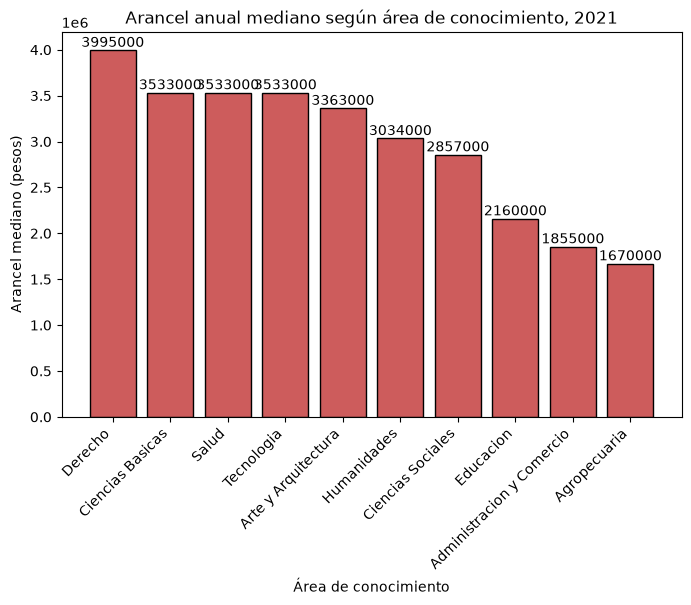

,Arancel mediano,Matrículas
AREA CONOCIMIENTO,,
Derecho,3995000.0,751
Ciencias Basicas,3533000.0,187
Salud,3533000.0,2899
Tecnologia,3533000.0,2979
Arte y Arquitectura,3363000.0,249
Humanidades,3034000.0,231
Ciencias Sociales,2857000.0,1972
Educacion,2160000.0,2060
Administracion y Comercio,1855000.0,2254


In [32]:
#Arancel mediano por área de conocimiento (criterio: mediana, robusta ante outliers)
mediana_area = df.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)'].median().sort_values(ascending=False)

tabla_area_arancel = pd.DataFrame({
    'Arancel mediano': mediana_area,
    'Matrículas': df.groupby('AREA CONOCIMIENTO').size().reindex(mediana_area.index)
})

fig, ax = plt.subplots(figsize=(8,5))
barras = ax.bar(tabla_area_arancel.index, tabla_area_arancel['Arancel mediano'],
                color='indianred', edgecolor='black')
ax.set_title('Arancel anual mediano según área de conocimiento, 2021')
ax.set_xlabel('Área de conocimiento')
ax.set_ylabel('Arancel mediano (pesos)')
ax.bar_label(barras, fmt='%.0f')
plt.xticks(rotation=45, ha='right')
plt.show()
tabla_area_arancel

**Respuesta**: sí. Considerando todas las matrículas, el área más cara es **Derecho**
(mediana \$3.995.000), seguida de Ciencias Básicas, Salud y Tecnología (\$3.533.000 en los tres casos).
Las más baratas son **Agropecuaria** (\$1.670.000) y **Administración y Comercio** (\$1.855.000).
La diferencia entre el área más cara y la más barata es de ≈ \$2.325.000 anuales, más del doble.

Sin embargo, esta comparación mezcla niveles: Agropecuaria parece barata porque la mayoría de sus
matrículas son técnicas. Al **estratificar por nivel de carrera** la conclusión se refina:

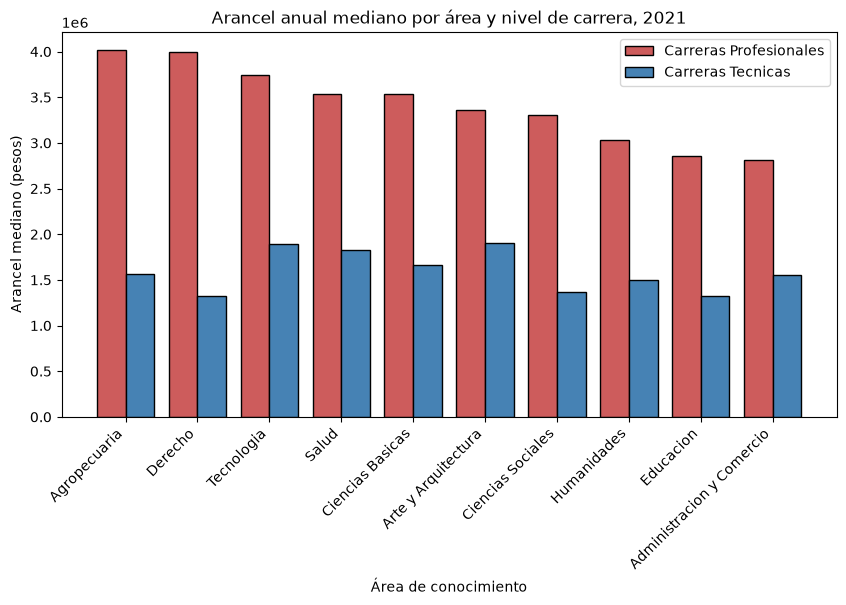

NIVEL CARRERA,Carreras Profesionales,Carreras Tecnicas
AREA CONOCIMIENTO,,
Agropecuaria,4015000.0,1559721.0
Derecho,3995000.0,1321425.0
Tecnologia,3745000.0,1890000.0
Salud,3533000.0,1823000.0
Ciencias Basicas,3533000.0,1664717.0
Arte y Arquitectura,3363000.0,1908000.0
Ciencias Sociales,3305000.0,1372550.0
Humanidades,3034000.0,1499400.0
Educacion,2857000.0,1323533.0


In [33]:
#Arancel mediano por área y nivel de carrera (solo carreras profesionales y técnicas)
sub = df[df['NIVEL CARRERA'].isin(['Carreras Profesionales', 'Carreras Tecnicas'])]

tabla_area_nivel = pd.crosstab(sub['AREA CONOCIMIENTO'], sub['NIVEL CARRERA'],
                               values=sub['VALOR ARANCEL (PESOS)'], aggfunc='median')
tabla_area_nivel = tabla_area_nivel.sort_values('Carreras Profesionales', ascending=False)

x = np.arange(len(tabla_area_nivel))
fig, ax = plt.subplots(figsize=(10,5))
b1 = ax.bar(x - 0.2, tabla_area_nivel['Carreras Profesionales'], width=0.4,
            color='indianred', edgecolor='black', label='Carreras Profesionales')
b2 = ax.bar(x + 0.2, tabla_area_nivel['Carreras Tecnicas'], width=0.4,
            color='steelblue', edgecolor='black', label='Carreras Tecnicas')
ax.set_title('Arancel anual mediano por área y nivel de carrera, 2021')
ax.set_xlabel('Área de conocimiento')
ax.set_ylabel('Arancel mediano (pesos)')
ax.set_xticks(x)
ax.set_xticklabels(tabla_area_nivel.index, rotation=45, ha='right')
ax.legend()
plt.show()
tabla_area_nivel

**Conclusión del criterio estratificado**:
- Entre las **carreras profesionales**, las más caras son Agropecuaria (\$4.015.000, que corresponde a
  Agronomía de la UTA), Derecho (\$3.995.000) y Tecnología (\$3.745.000); la más barata es
  Administración y Comercio (\$2.818.000).
- Entre las **carreras técnicas**, todas las áreas se mueven entre \$1.3 y \$1.9 millones; las más caras
  son Tecnología (\$1.890.000) y Salud (\$1.823.000), y la más barata Derecho (\$1.321.425, técnico
  jurídico).
- Por lo tanto, **sí hay áreas sistemáticamente más caras** (Derecho, Agropecuaria, Tecnología y Salud
  en el nivel profesional), y el nivel de la carrera pesa tanto como el área: una carrera profesional
  cuesta en mediana ≈ el doble que una técnica en cualquier área.

## 2.2 ¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?

**Criterio**: comparamos la **media y mediana de edad** por tipo de institución y construimos una
tabla de doble entrada `RANGO EDAD × TIPO DE INSTITUCION` con porcentajes por fila (dentro de cada
tramo de edad, cómo se distribuyen entre tipos de institución).

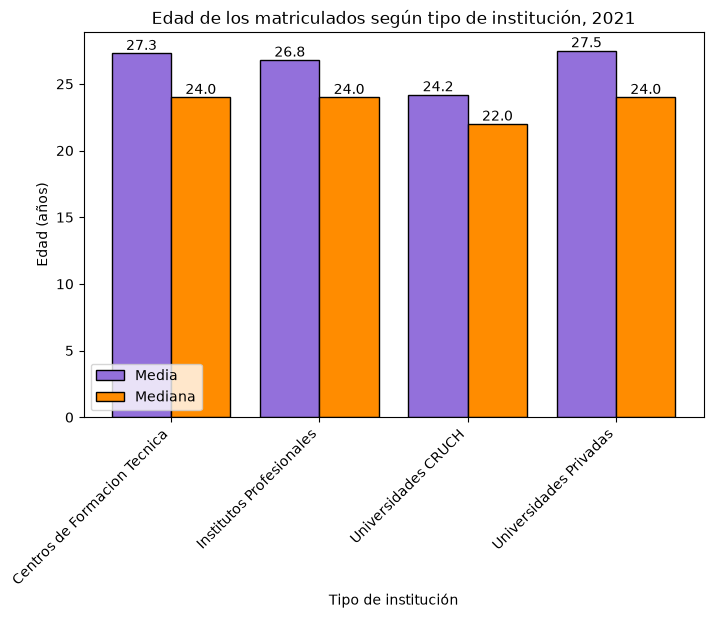

,Edad media,Edad mediana,Matrículas
TIPO DE INSTITUCION,,,
Centros de Formacion Tecnica,27.3,24.0,3594
Institutos Profesionales,26.8,24.0,1430
Universidades CRUCH,24.2,22.0,7849
Universidades Privadas,27.5,24.0,1243


In [34]:
#Media y mediana de EDAD por tipo de institución
tabla_edad_inst = df.groupby('TIPO DE INSTITUCION')['EDAD'].agg(['mean', 'median', 'size']).round(1)
tabla_edad_inst.columns = ['Edad media', 'Edad mediana', 'Matrículas']

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(tabla_edad_inst))
b1 = ax.bar(x - 0.2, tabla_edad_inst['Edad media'], width=0.4, color='mediumpurple',
            edgecolor='black', label='Media')
b2 = ax.bar(x + 0.2, tabla_edad_inst['Edad mediana'], width=0.4, color='darkorange',
            edgecolor='black', label='Mediana')
ax.set_title('Edad de los matriculados según tipo de institución, 2021')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Edad (años)')
ax.set_xticks(x)
ax.set_xticklabels(tabla_edad_inst.index, rotation=45, ha='right')
ax.bar_label(b1, fmt='%.1f')
ax.bar_label(b2, fmt='%.1f')
ax.legend()
plt.show()
tabla_edad_inst

In [35]:
#Porcentajes por fila: dentro de cada rango de edad, distribución entre tipos de institución
pd.crosstab(df['RANGO EDAD'], df['TIPO DE INSTITUCION'], normalize='index').round(3)*100

TIPO DE INSTITUCION,Centros de Formacion Tecnica,Institutos Profesionales,Universidades CRUCH,Universidades Privadas
RANGO EDAD,,,,
15 a 19,19.9,7.0,68.3,4.7
20 a 24,21.7,9.2,60.6,8.4
25 a 29,27.5,12.1,50.6,9.8
30 a 34,35.3,14.8,39.3,10.6
35 a 39,37.5,12.4,37.1,13.1
40 y mas,40.2,12.2,33.3,14.2


**Respuesta**: la edad **sí influye** en el tipo de institución:
- Los estudiantes más **jóvenes** se concentran en las **Universidades CRUCH** (principalmente la U. de
  Tarapacá): su edad mediana es 22 años (media 24,2), y entre los menores de 20 años el 68,3 % se
  matricula en universidades CRUCH.
- Los estudiantes de **mayor edad** prefieren instituciones técnico-profesionales y privadas: la edad
  mediana en CFT, IP y Universidades Privadas es 24 años en los tres casos (medias de 27,3; 26,8 y
  27,5). La participación de las universidades CRUCH cae sostenidamente con la edad (68,3 % en el
  tramo 15-19 → 33,3 % en 40 y más), mientras que la de los CFT sube (19,9 % → 40,2 %).
- Interpretación: la universidad tradicional atrae al recién egresado de enseñanza media (vía
  PAES/ admisión tradicional), mientras que CFT, IP y universidades privadas —con jornadas
  vespertinas y programas más cortos— captan a adultos que trabajan y buscan formación técnica o
  reconversión laboral. Esto es coherente con el 29 % de matrícula vespertina observado en el Ítem 1.

## 2.3 ¿Hay carreras cuyo arancel sea sustantivamente más caro que la mayoría?

**Criterio**: usamos dos umbrares complementarios:
1. **Regla de Tukey** (outlier extremo): $Q_3 + 1{,}5 \cdot RIC$ = \$3.533.000 + 1,5·\$1.683.000 =
   \$6.057.500. Como el arancel máximo es \$5.595.000, **ninguna carrera califica como outlier
   estadístico extremo**.
2. **Percentil 95**: definimos "sustantivamente más caro que la mayoría" como arancel ≥ P95 =
   \$3.995.000 (el 5 % más caro del total de matrículas). Identificamos qué carreras cumplen esto y
   las describimos con las variables de la base (institución, área, nivel, duración, acreditación).

In [36]:
#Umbrales: Tukey y percentil 95
q1 = df['VALOR ARANCEL (PESOS)'].quantile(0.25)
q3 = df['VALOR ARANCEL (PESOS)'].quantile(0.75)
ric = q3 - q1
tukey = q3 + 1.5*ric
p95 = df['VALOR ARANCEL (PESOS)'].quantile(0.95)

print(f"Q1 = ${q1:,.0f}   Q3 = ${q3:,.0f}   RIC = ${ric:,.0f}")
print(f"Umbral de Tukey (Q3 + 1.5*RIC) = ${tukey:,.0f}")
print(f"Arancel máximo observado       = ${df['VALOR ARANCEL (PESOS)'].max():,.0f}")
print(f"Percentil 95                   = ${p95:,.0f}")
print(f"Matrículas sobre el P95        = {(df['VALOR ARANCEL (PESOS)'] >= p95).sum()} "
      f"({round((df['VALOR ARANCEL (PESOS)'] >= p95).mean()*100,1)} %)")

Q1 = $1,850,000   Q3 = $3,533,000   RIC = $1,683,000
Umbral de Tukey (Q3 + 1.5*RIC) = $6,057,500
Arancel máximo observado       = $5,595,000
Percentil 95                   = $3,995,000
Matrículas sobre el P95        = 825 (5.8 %)


In [37]:
#¿Qué carreras están sobre el P95? Se describen con otras variables de la base
caras = df['VALOR ARANCEL (PESOS)'] >= p95

tabla_caras = df[caras].groupby(
    ['NOMBRE CARRERA', 'NOMBRE DE INSTITUCION', 'AREA CONOCIMIENTO', 'NIVEL CARRERA',
     'DURACION TOTAL CARRERA (SEMESTRES)'], observed=True
).agg(
    arancel=('VALOR ARANCEL (PESOS)', 'median'),
    matricula=('VALOR MATRICULA (PESOS)', 'median'),
    matriculas=('ID', 'size')
).sort_values('arancel', ascending=False)
tabla_caras

arancel  \
NOMBRE CARRERA NOMBRE DE INSTITUCION   AREA CONOCIMIENTO NIVEL CARRERA          DURACION TOTAL CARRERA (SEMESTRES)              
MEDICINA       UNIVERSIDAD DE TARAPACA Salud             Carreras Profesionales 14                                  5595000.0   
AGRONOMIA      UNIVERSIDAD DE TARAPACA Agropecuaria      Carreras Profesionales 10                                  4015000.0   
DERECHO        UNIVERSIDAD DE TARAPACA Derecho           Carreras Profesionales 10                                  3995000.0   
                                                                                11                                  3995000.0   

                                                                                                                    matricula  \
NOMBRE CARRERA NOMBRE DE INSTITUCION   AREA CONOCIMIENTO NIVEL CARRERA          DURACION TOTAL CARRERA (SEMESTRES)              
MEDICINA       UNIVERSIDAD DE TARAPACA Salud             Carreras Profesionales 14                                   155000.0   
AGRONOMIA      UNIVERSIDAD DE TARAPACA Agropecuaria      Carreras Profesionales 10                                   155000.0   
DERECHO        UNIVERSIDAD DE TARAPACA Derecho           Carreras Profesionales 10                                   155000.0   
                                                                                11                                   155000.0   

                                                                                                                    matriculas  
NOMBRE CARRERA NOMBRE DE INSTITUCION   AREA CONOCIMIENTO NIVEL CARRERA          DURACION TOTAL CARRERA (SEMESTRES)              
MEDICINA       UNIVERSIDAD DE TARAPACA Salud             Carreras Profesionales 14                                         157  
AGRONOMIA      UNIVERSIDAD DE TARAPACA Agropecuaria      Carreras Profesionales 10                                         174  
DERECHO        UNIVERSIDAD DE TARAPACA Derecho           Carreras Profesionales 10                                         281  
                                                                                11                                         213

Mediana arancel carreras >= P95 : $3,995,000
Mediana arancel del resto       : $2,857,000


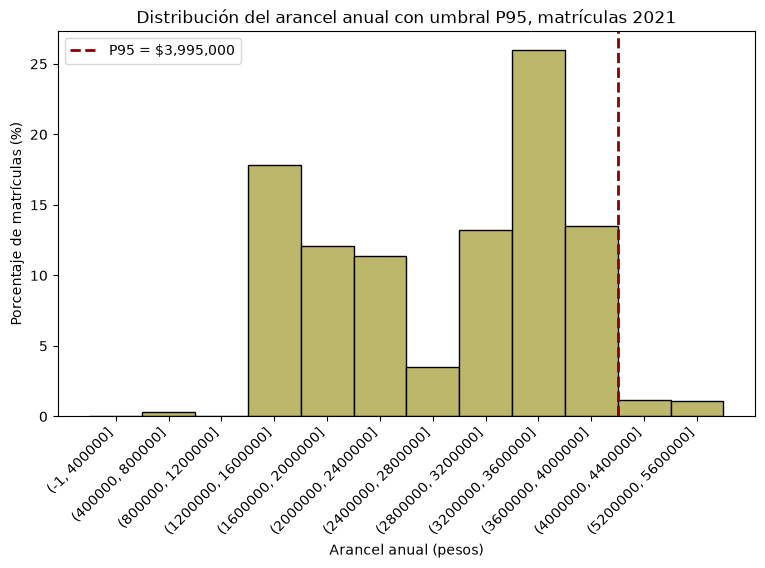

In [38]:
#Comparación: arancel mediano de las carreras caras vs el resto
print(f"Mediana arancel carreras >= P95 : ${df.loc[caras,'VALOR ARANCEL (PESOS)'].median():,.0f}")
print(f"Mediana arancel del resto       : ${df.loc[~caras,'VALOR ARANCEL (PESOS)'].median():,.0f}")

#Histograma del arancel con el umbral P95 destacado
categorias = tabla_arancel.index
f = tabla_arancel['hi']
fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(categorias.astype(str), f, color='darkkhaki', edgecolor='black', width=1)
ax.axvline(x=9.5, color='darkred', linestyle='--', linewidth=2,
           label=f'P95 = ${p95:,.0f}')  # borde del intervalo (3.6M, 4.0M] que contiene al P95
ax.set_title('Distribución del arancel anual con umbral P95, matrículas 2021')
ax.set_xlabel('Arancel anual (pesos)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.show()

**Respuesta**: sí, hay carreras sustantivamente más caras que la mayoría. Sobre el umbral P95
(\$3.995.000) se encuentran **solo 4 combinaciones carrera-institución, todas de la Universidad de
Tarapacá**:

| Carrera | Arancel | Duración | Área |
|---|---|---|---|
| **Medicina** | \$5.595.000 | 14 semestres | Salud |
| **Agronomía** | \$4.015.000 | 10 semestres | Agropecuaria |
| **Derecho** | \$3.995.000 | 10-11 semestres | Derecho |

**Explicación a partir de las variables de la base y el contexto regional**:
- **Medicina** es, por lejos, la más cara (\$5.595.000, casi el doble —+96 %— de la mediana general):
  es la única
  carrera de la región con 14 semestres de duración, pertenece al área Salud (altos costos de
  laboratorios, campos clínicos hospitalarios y cuerpo docente especializado) y la UTA es la única
  institución de Arica y Parinacota que la imparte.
- **Agronomía** responde al perfil productivo de la región: el valle de Azapa y la agricultura del
  extremo norte requieren formación especializada de laboratorio y terreno, y nuevamente la UTA es
  el único oferente.
- **Derecho** es la carrera profesional más demandada fuera del área salud (494 matrículas sobre el
  P95) y su arancel de \$3.995.000 es el tope de las carreras de 10-11 semestres.
- En todos los casos se trata de **carreras profesionales largas (10-14 semestres) de la universidad
  estatal regional**, que fija un arancel único alto para sus programas tradicionales. En una región
  fronteriza y aislada como Arica y Parinacota, la oferta es limitada (11 instituciones, 146 carreras)
  y las carreras de mayor prestigio y duración no tienen competencia local que presione los precios a
  la baja; la alternativa para la mayoría de los estudiantes son las carreras técnicas, cuyo arancel
  mediano es menos de la mitad.

---
## Síntesis general

- La matrícula 2021 de Arica y Parinacota (14.116 registros) está dominada por la **Universidad de
  Tarapacá** (50,4 % de las matrículas; CRUCH 55,6 %), con mayoría **femenina** (56,6 %),
  **joven** (mediana 23 años) y en jornada **diurna** (70,6 %).
- El arancel anual mediano es \$2.857.000, con fuerte dependencia del **nivel** (profesional ≈ 2×
  técnica) y del **área** (Derecho, Agropecuaria, Tecnología y Salud las más caras al nivel
  profesional).
- La **edad** ordena el sistema: los jóvenes van a la universidad CRUCH; los adultos a CFT, IP y
  universidades privadas.
- Las carreras sustantivamente más caras son **Medicina, Agronomía y Derecho de la UTA**, explicado
  por duración, área, acreditación y la posición monopólica de la universidad estatal en la región.